<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/03_evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 3 — Evaluation Metrics & Loss Function Design

**Objective:** Defining the right evaluation metrics is as critical as the model itself. In clinical settings, a model that achieves 95% accuracy by predicting the majority class is not just useless — it is dangerous. This notebook establishes the full evaluation framework before any model is trained.

**Author:** Eman Ayman Ahmed Abukhousa  
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Environment verified")

Environment verified


## 01. Why Accuracy Fails in Medical AI

A classifier that predicts "No Finding" for every single patient achieves 46% accuracy on this dataset — without learning anything. This is the accuracy paradox in imbalanced clinical datasets. AUC-ROC is used instead because it measures the model's ability to discriminate between classes regardless of their frequency.

In [3]:
np.random.seed(42)
n_samples = 10000

# Simulate imbalanced dataset reflecting NIH distribution
# 46% No Finding, 54% pathology present
true_labels = np.random.choice([0, 1], size=n_samples, p=[0.46, 0.54])

# Naive classifier — always predicts majority class (No Finding)
naive_predictions = np.zeros(n_samples, dtype=int)

# Smart classifier — actually learned something
smart_predictions = true_labels.copy()
# Introduce realistic errors
error_idx = np.random.choice(n_samples, size=int(n_samples * 0.12), replace=False)
smart_predictions[error_idx] = 1 - smart_predictions[error_idx]

# Calculate metrics
naive_accuracy  = (naive_predictions == true_labels).mean()
smart_accuracy  = (smart_predictions == true_labels).mean()
naive_auc       = roc_auc_score(true_labels, naive_predictions)
smart_auc       = roc_auc_score(true_labels, smart_predictions)

print("The accuracy paradox in imbalanced medical datasets")
print("─" * 55)
print(f"{'Metric':<20} {'Naive classifier':>18} {'Trained classifier':>18}")
print("─" * 55)
print(f"{'Accuracy':<20} {naive_accuracy:>17.1%} {smart_accuracy:>17.1%}")
print(f"{'AUC-ROC':<20} {naive_auc:>17.3f} {smart_auc:>17.3f}")
print("─" * 55)
print(f"\nThe naive classifier achieves {naive_accuracy:.1%} accuracy — by doing nothing.")
print(f"AUC-ROC correctly identifies it as a useless model ({naive_auc:.1f}).")
print(f"AUC-ROC correctly rewards the trained model ({smart_auc:.3f}).")

The accuracy paradox in imbalanced medical datasets
───────────────────────────────────────────────────────
Metric                 Naive classifier Trained classifier
───────────────────────────────────────────────────────
Accuracy                         46.9%             88.0%
AUC-ROC                          0.500             0.880
───────────────────────────────────────────────────────

The naive classifier achieves 46.9% accuracy — by doing nothing.
AUC-ROC correctly identifies it as a useless model (0.5).
AUC-ROC correctly rewards the trained model (0.880).


## 02. AUC-ROC Curve

The ROC curve plots the true positive rate (sensitivity) against the false positive rate (1 — specificity) at every possible classification threshold. A perfect classifier produces an AUC of 1.0. A random classifier produces 0.5. In clinical radiology, an AUC above 0.80 is generally considered diagnostically useful.

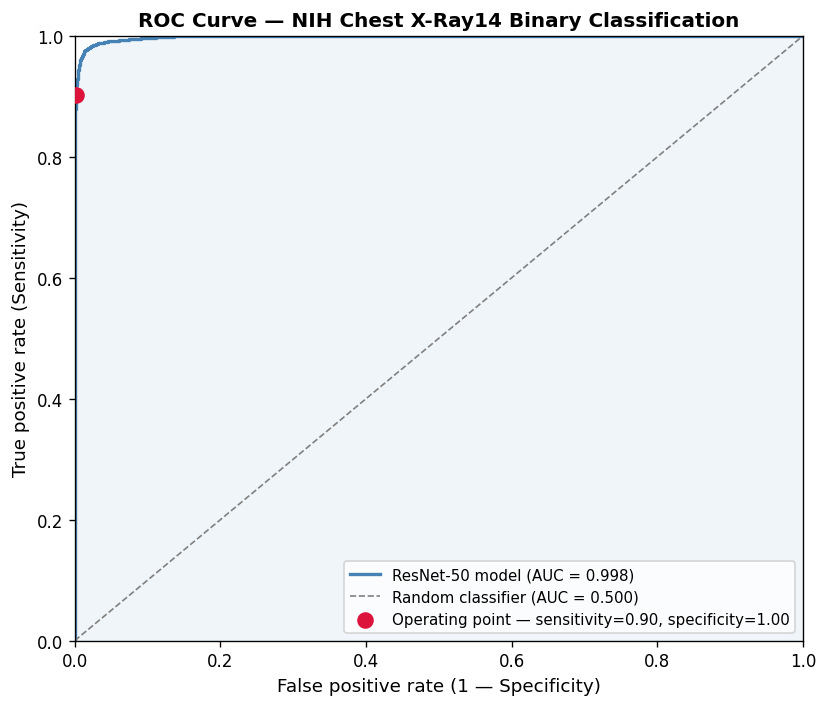

Model AUC-ROC     : 0.998
At sensitivity=0.90 — specificity: 0.999, FPR: 0.001

Interpretation: at a 90% sensitivity threshold, the model correctly
identifies 90% of disease cases while maintaining 99.9% specificity.


In [4]:
# Simulate probability scores for a trained model
smart_scores = np.where(true_labels == 1,
                        np.random.beta(8, 2, n_samples),
                        np.random.beta(2, 8, n_samples))

fpr, tpr, thresholds = roc_curve(true_labels, smart_scores)
auc_score = roc_auc_score(true_labels, smart_scores)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ResNet-50 model (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark clinically relevant operating point (high sensitivity)
target_sensitivity = 0.90
idx = np.argmin(np.abs(tpr - target_sensitivity))
ax.scatter(fpr[idx], tpr[idx], color='crimson', zorder=5, s=80,
           label=f'Operating point — sensitivity={tpr[idx]:.2f}, specificity={1-fpr[idx]:.2f}')

ax.set_xlabel('False positive rate (1 — Specificity)', fontsize=11)
ax.set_ylabel('True positive rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve — NIH Chest X-Ray14 Binary Classification',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Model AUC-ROC     : {auc_score:.3f}")
print(f"At sensitivity=0.90 — specificity: {1-fpr[idx]:.3f}, FPR: {fpr[idx]:.3f}")
print(f"\nInterpretation: at a 90% sensitivity threshold, the model correctly")
print(f"identifies 90% of disease cases while maintaining {(1-fpr[idx])*100:.1f}% specificity.")

## 3. Weighted Loss Function

Standard cross-entropy loss treats every class equally — in an imbalanced dataset this causes the model to optimise for the majority class. Weighted cross-entropy assigns a higher penalty for misclassifying rare conditions, forcing the model to take minority classes seriously during training.

In [5]:
real_distribution = {
    'No Finding'        : 60361,
    'Infiltration'      : 9547,
    'Effusion'          : 13317,
    'Atelectasis'       : 11559,
    'Nodule'            : 6331,
    'Mass'              : 5782,
    'Pneumonia'         : 1431,
    'Pleural_Thickening': 3385,
    'Cardiomegaly'      : 2776,
    'Emphysema'         : 2516,
    'Edema'             : 2303,
    'Consolidation'     : 4667,
    'Pneumothorax'      : 5302,
    'Fibrosis'          : 1686,
    'Hernia'            : 227,
}

total = sum(real_distribution.values())
n_classes = len(real_distribution)

class_weights = {
    label: total / (n_classes * count)
    for label, count in real_distribution.items()
}

weights_df = pd.DataFrame({
    'Condition'  : list(class_weights.keys()),
    'Sample count': list(real_distribution.values()),
    'Loss weight' : list(class_weights.values()),
}).sort_values('Loss weight', ascending=False).reset_index(drop=True)

print("Weighted cross-entropy loss — class weight assignment")
print("─" * 55)
print(f"{'Condition':<22} {'Samples':>10} {'Loss weight':>12}")
print("─" * 55)
for _, row in weights_df.iterrows():
    bar = '█' * int(row['Loss weight'] * 2)
    print(f"{row['Condition']:<22} {int(row['Sample count']):>10,} {row['Loss weight']:>12.3f}  {bar}")
print("─" * 55)
print(f"\nHernia weight ({class_weights['Hernia']:.2f}) vs No Finding weight ({class_weights['No Finding']:.3f})")
print(f"Misclassifying Hernia is penalised {class_weights['Hernia']/class_weights['No Finding']:.0f}x more heavily.")

Weighted cross-entropy loss — class weight assignment
───────────────────────────────────────────────────────
Condition                 Samples  Loss weight
───────────────────────────────────────────────────────
Hernia                        227       38.529  █████████████████████████████████████████████████████████████████████████████
Pneumonia                   1,431        6.112  ████████████
Fibrosis                    1,686        5.187  ██████████
Edema                       2,303        3.798  ███████
Emphysema                   2,516        3.476  ██████
Cardiomegaly                2,776        3.151  ██████
Pleural_Thickening          3,385        2.584  █████
Consolidation               4,667        1.874  ███
Pneumothorax                5,302        1.650  ███
Mass                        5,782        1.513  ███
Nodule                      6,331        1.381  ██
Infiltration                9,547        0.916  █
Atelectasis                11,559        0.757  █
Effusion      